# Описание ДЗ-3.

В третьей домашке необходимо для датасета животных обучить MLP.
2. Использовать Custom Dataset, Sampler, collate_fn
3. Сделать предобработку фичей
4. Попробовать BatchNorm1d, Dropout
5. Подключить для логирования tensorboard и/или mlflow
6. Не забыть разделить выборку на train/valid в соотношении 80/20%
7. Получить точность не ниже 65%.
8. Сравнить результаты при разных подходах: 1) Масштабировать данные StandardScaler'ом + не использовать BatchNorm после Input слоя 2) Не Масштабировать данные + использовать BatchNorm после Input слоя 3) StandardScaler + BatchNorm

*В папке LESS  можно найти примеры использования всех необходимых либ для выполнения данной работы*

За дз можно получить максимум 15 баллов. **Домашки довольно творческие, если замечу копию нотбука у другого студента то максимальный балл сниижается до 3 )**

Разбалловка:
*   **Воспроизводимость и читабельность кода -  11 баллов** (все воспроизвелось и все понятно для проверяющего - 11 баллов; есть непонятные моменты, но все воспроизвелось - 6 балла; непонятный код и/или воспроизводится с небольшой правкой - 3 балл; непонятный код и/или ничего не воспроизвелось - 0 баллов).
*   **Технический отчет - 4 балла** (приведены результаты сравнения и выводы что сделали чтоб перебить baseline\другую модель, к примеру одна модель лучше/хуже нейронки и тд - 4 балла, только результаты - 2 балл, ничего нет - 0 баллов).


**Присылать домашки по ссылке https://forms.gle/W8jwbwA4EWagEbX66**

In [73]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Sampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import mlflow
from torch.utils.tensorboard import SummaryWriter
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import sklearn.preprocessing as ppc
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import warnings

warnings.filterwarnings("ignore")

In [74]:
torch.zeros(1).cuda()

tensor([0.], device='cuda:0')

In [75]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [76]:
torch.manual_seed(69)
np.random.seed(69)

SEED = 69

### функции

In [77]:
def build_pipe(data: pd.DataFrame) -> Pipeline:
    categorical_cols = data.select_dtypes(
        include=[
            "object",
            "category",
        ]
    ).columns.tolist()

    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="mean")),
                                    (
                                        "transformer",
                                        ppc.SplineTransformer(
                                            n_knots=7,
                                            degree=7,
                                            order="F",
                                            extrapolation="linear",
                                        ),
                                    ),
                                ]
                            ),
                            num_cols,
                        ),
                        (
                            "cat",
                            Pipeline(
                                steps=[
                                    (
                                        "encoder",
                                        ppc.OneHotEncoder(handle_unknown="ignore"),
                                    )
                                ]
                            ),
                            categorical_cols,
                        ),
                    ]
                ),
            ),
            # ("poly", ppc.PolynomialFeatures(2)),
        ]
    )

In [78]:
class AnimalDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        self.features = features
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]

        if self.transform:
            x = self.transform(x)

        return x, y


def collate_fn(batch):
    features = torch.tensor([item[0] for item in batch], dtype=torch.float32)
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return features, labels

In [79]:
class StratifiedBatchSampler(Sampler):
    def __init__(self, y, batch_size, shuffle=True):
        if torch.is_tensor(y):
            y = y.numpy()
        assert len(y.shape) == 1, "y must be 1-D array"

        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.classes, self.counts = np.unique(self.y, return_counts=True)
        self.class_to_indices = {
            cls: np.where(self.y == cls)[0] for cls in self.classes
        }

        self.samples_per_class = {cls: 0 for cls in self.classes}

        remaining = self.batch_size
        for i, cls in enumerate(self.classes):
            class_count = self.counts[i]
            if i == len(self.classes) - 1:
                self.samples_per_class[cls] = remaining
            else:
                self.samples_per_class[cls] = max(
                    1, int(self.batch_size * class_count / len(self.y))
                )
                remaining -= self.samples_per_class[cls]

        self.n_batches = int(np.ceil(len(self.y) / self.batch_size))

    def __iter__(self):
        indices = []
        class_indices = {cls: 0 for cls in self.classes}

        if self.shuffle:
            for cls in self.classes:
                np.random.shuffle(self.class_to_indices[cls])

        for _ in range(self.n_batches):
            batch_indices = []

            for cls in self.classes:
                cls_indices = self.class_to_indices[cls]
                start_idx = class_indices[cls]
                samples_to_add = min(
                    self.samples_per_class[cls], len(cls_indices) - start_idx
                )

                if samples_to_add > 0:
                    batch_indices.extend(
                        cls_indices[start_idx : start_idx + samples_to_add]
                    )
                    class_indices[cls] += samples_to_add

                if class_indices[cls] >= len(cls_indices):
                    if self.shuffle:
                        np.random.shuffle(cls_indices)
                    class_indices[cls] = 0

            while len(batch_indices) < self.batch_size and len(batch_indices) > 0:
                extra_indices = np.random.choice(
                    batch_indices,
                    size=min(self.batch_size - len(batch_indices), len(batch_indices)),
                    replace=False,
                )
                batch_indices.extend(extra_indices)

            indices.append(batch_indices[: self.batch_size])

        return iter([idx for batch in indices for idx in batch])

    def __len__(self):
        return len(self.y)

In [80]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        use_batchnorm=True,
        dropout_rate=0.5,
    ):
        super(MLP, self).__init__()

        self.use_batchnorm = use_batchnorm
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) if use_batchnorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size // 2, output_size)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x


def train_model(
    X_train,
    y_train,
    X_test,
    y_test,
    use_scaler=True,
    use_batchnorm=True,
    hidden_size=128,
    batch_size=32,
    lr=0.001,
    epochs=10,
):

    if use_scaler:
        scaler = ppc.StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    train_dataset = AnimalDataset(X_train, y_train)
    val_dataset = AnimalDataset(X_test, y_test)

    train_sampler = StratifiedBatchSampler(y_train, batch_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    input_size = X_train.shape[1]
    output_size = len(np.unique(y_train))

    model = MLP(input_size, hidden_size, output_size, use_batchnorm=use_batchnorm)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    writer = SummaryWriter(
        f"runs/animal_model_scaler_{use_scaler}_batchnorm_{use_batchnorm}"
    )

    mlflow.set_experiment("Animal_Classification_MLP")

    with mlflow.start_run(
        run_name=f"mlp_scaler_{use_scaler}_batchnorm_{use_batchnorm}"
    ):
        mlflow.log_params(
            {
                "hidden_size": hidden_size,
                "batch_size": batch_size,
                "learning_rate": lr,
                "epochs": epochs,
                "use_scaler": use_scaler,
                "use_batchnorm": use_batchnorm,
            }
        )

        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            train_preds = []
            train_true = []

            for features, labels in tqdm(
                train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"
            ):
                features = features.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                train_preds.extend(predicted.cpu().numpy())
                train_true.extend(labels.cpu().numpy())

            model.eval()
            val_loss = 0.0
            val_preds = []
            val_true = []

            with torch.no_grad():
                for features, labels in val_loader:
                    features = features.to(device)
                    labels = labels.to(device)

                    outputs = model(features)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    val_preds.extend(predicted.cpu().numpy())
                    val_true.extend(labels.cpu().numpy())

            train_loss /= len(train_loader)
            val_loss /= len(val_loader)
            train_acc = accuracy_score(train_true, train_preds)
            val_acc = accuracy_score(val_true, val_preds)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/validation", val_loss, epoch)
            writer.add_scalar("Accuracy/train", train_acc, epoch)
            writer.add_scalar("Accuracy/validation", val_acc, epoch)

            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "train_accuracy": train_acc,
                    "val_accuracy": val_acc,
                },
                step=epoch,
            )

            print(
                f"Epoch {epoch+1}/{epochs} - "
                f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}, "
                f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}"
            )

        mlflow.pytorch.log_model(model, "model")
        writer.close()

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train")
        plt.plot(val_losses, label="Validation")
        plt.title("Loss Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label="Train")
        plt.plot(val_accs, label="Validation")
        plt.title("Accuracy Curves")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.tight_layout()
        plt.show()

        return model, val_acc

### код

In [81]:
X = pd.read_csv("./data/X_cat.csv", sep="\t")
y = pd.read_csv("./data/y_cat.csv", sep="\t")

df = pd.merge(X, y, on="Id", how="inner")
df.drop(columns=["Id"], inplace=True)
df.head()

target_col = "Status"

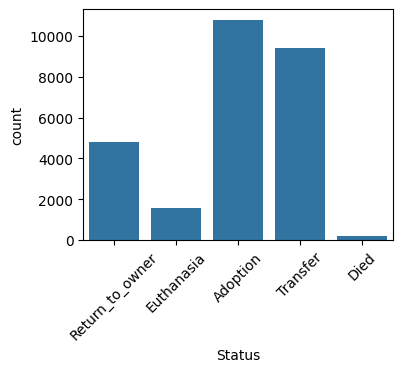

In [82]:
plt.figure(figsize=(4, 3))
sns.countplot(x="Status", data=df)
plt.xticks(rotation=45)
plt.show()

In [83]:
X = df.drop(target_col, axis=1).values
y = pd.Categorical(df[target_col]).codes

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

In [84]:
pipe = build_pipe(data=pd.DataFrame(X_train))
X_train_processed = pipe.fit_transform(X_train)
X_test_processed = pipe.transform(X_test)


1. StandardScaler + No BatchNorm


Epoch 1/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 1/10 - Train loss: 0.9639, Train acc: 0.6236, Val loss: 0.8726, Val acc: 0.6618


Epoch 2/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 2/10 - Train loss: 0.8784, Train acc: 0.6556, Val loss: 0.8643, Val acc: 0.6655


...

Epoch 9/10 - Train loss: 0.8298, Train acc: 0.6682, Val loss: 0.8323, Val acc: 0.6665


Epoch 10/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

2025/05/26 20:14:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 10/10 - Train loss: 0.8229, Train acc: 0.6698, Val loss: 0.8344, Val acc: 0.6670


2025/05/26 20:14:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/26 20:14:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


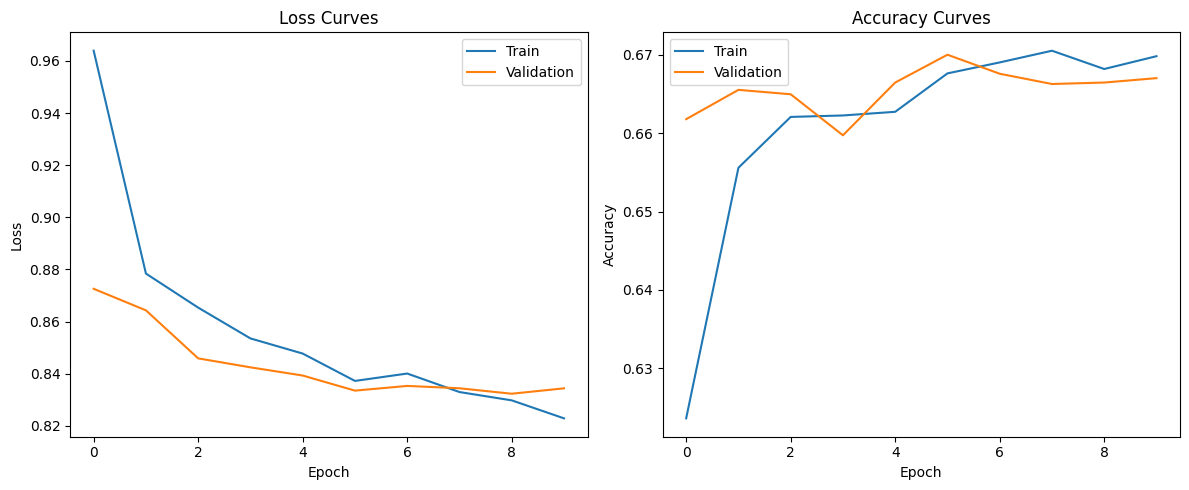


2. No StandardScaler + BatchNorm


Epoch 1/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 1/10 - Train loss: 0.9685, Train acc: 0.6233, Val loss: 0.8862, Val acc: 0.6519


Epoch 2/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 2/10 - Train loss: 0.8910, Train acc: 0.6493, Val loss: 0.8677, Val acc: 0.6541


...

Epoch 9/10 - Train loss: 0.8315, Train acc: 0.6695, Val loss: 0.8386, Val acc: 0.6654


Epoch 10/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

2025/05/26 20:14:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 10/10 - Train loss: 0.8298, Train acc: 0.6669, Val loss: 0.8334, Val acc: 0.6633


2025/05/26 20:14:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/26 20:14:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


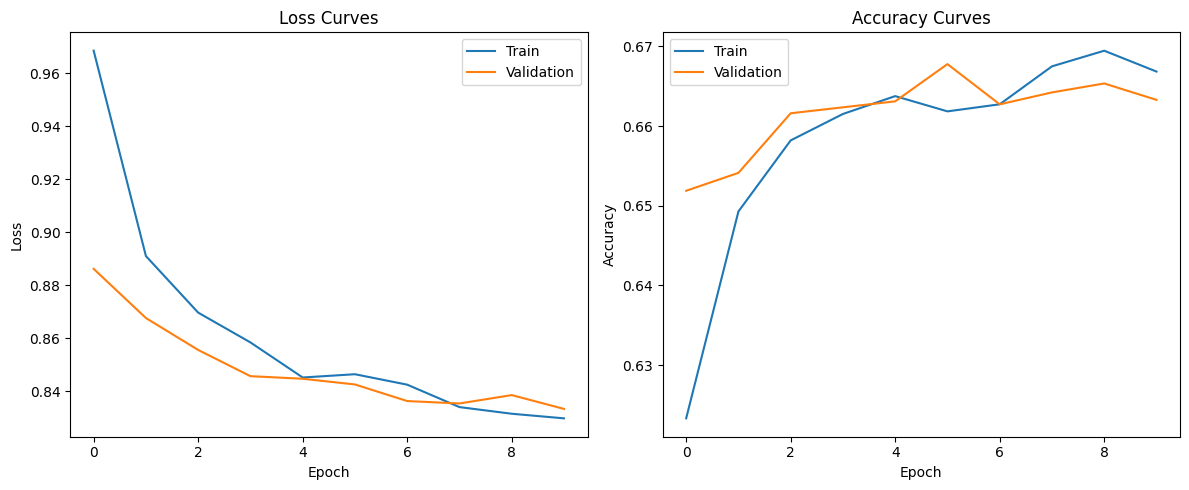


3. StandardScaler + BatchNorm


Epoch 1/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 1/10 - Train loss: 0.9605, Train acc: 0.6276, Val loss: 0.8767, Val acc: 0.6571


Epoch 2/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

Epoch 2/10 - Train loss: 0.8801, Train acc: 0.6550, Val loss: 0.8537, Val acc: 0.6582


...

Epoch 9/10 - Train loss: 0.8298, Train acc: 0.6699, Val loss: 0.8359, Val acc: 0.6659


Epoch 10/10 - Training:   0%|          | 0/669 [00:00<?, ?it/s]

2025/05/26 20:14:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 10/10 - Train loss: 0.8250, Train acc: 0.6698, Val loss: 0.8312, Val acc: 0.6659


2025/05/26 20:15:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/26 20:15:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


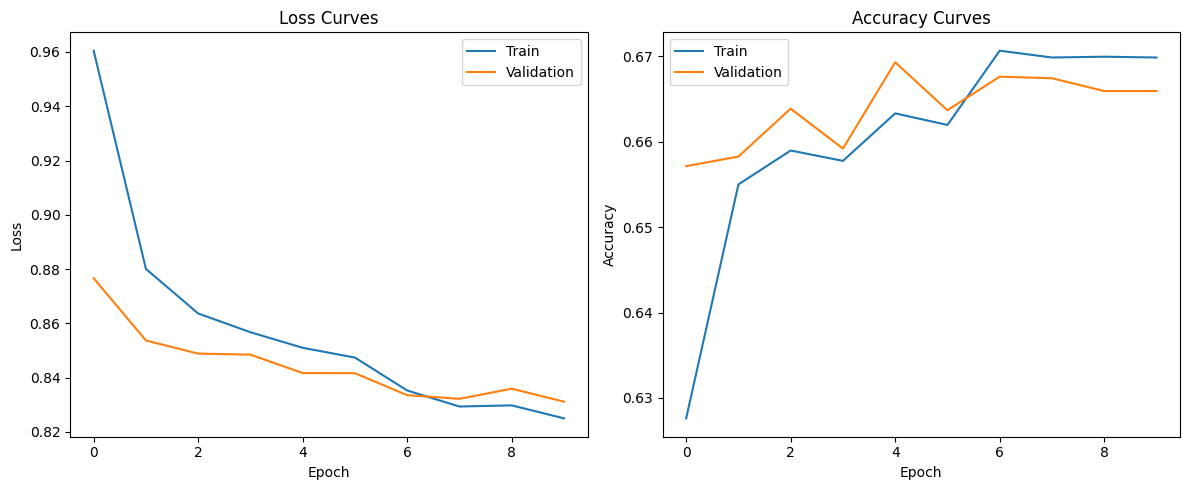

In [85]:
results = {}

print("\n1. StandardScaler + No BatchNorm")
model1, acc1 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=True,
    use_batchnorm=False,
)
results["StandardScaler + No BatchNorm"] = acc1

print("\n2. No StandardScaler + BatchNorm")
model2, acc2 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=False,
    use_batchnorm=True,
)
results["No StandardScaler + BatchNorm"] = acc2

print("\n3. StandardScaler + BatchNorm")
model3, acc3 = train_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    use_scaler=True,
    use_batchnorm=True,
)
results["StandardScaler + BatchNorm"] = acc3

StandardScaler + No BatchNorm: 0.6670
No StandardScaler + BatchNorm: 0.6633
StandardScaler + BatchNorm: 0.6659


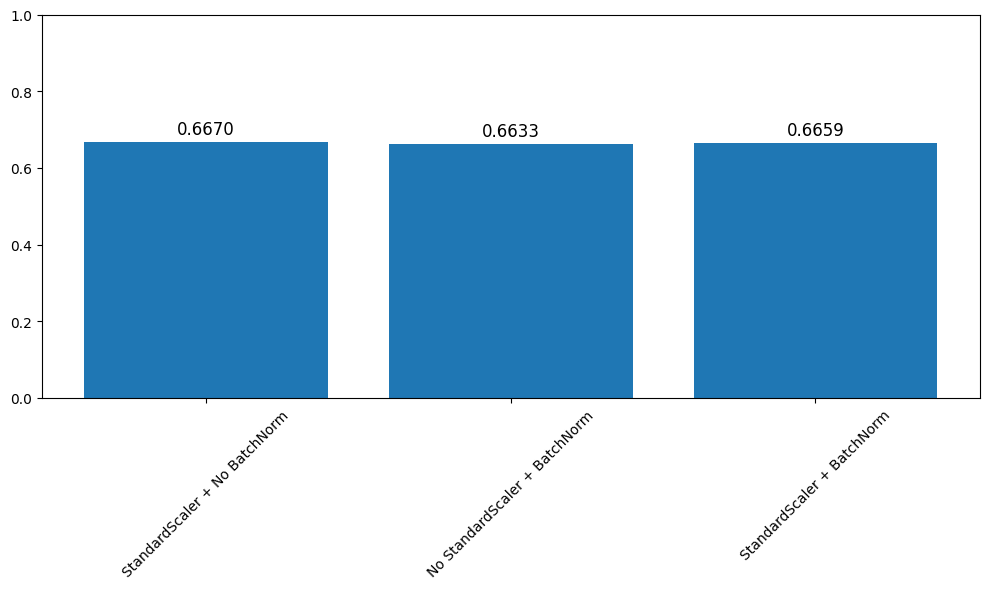

In [86]:
for config, acc in results.items():
    print(f"{config}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()

for i, (config, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha="center", va="bottom", fontsize=12)

plt.show()

вывод: все подходы дают примерно одинаковый результат. если поставить shuffle=False, то результаты самую малость лучше

